# Hierarchical Clustering

Tokenization & Cleaning: They strip PII (Personally Identifiable Information) and noise. **No need here**

Vector Embeddings: They convert sentences into vector representations (numbers) using a Transformer model (likely a variant of BERT or RoBERTa). This ensures the AI understands that "too expensive" and "costs a fortune" are semantically identical.

Hierarchical Clustering: Thematic groups these vectors into clusters. If many users say "login failed," "can't sign in," and "password error," these vectors cluster together to form a new theme automatically.

Taxonomy Mapping: The system organizes these clusters into a 2-3 level hierarchy (e.g., Product > Usability > Login).

In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv('data/cleaned_data/cleaned_Study_1_reviews.csv')
df.columns

Index(['ID', 'finalReview', 'Satisfaction_final', 'cleaning_service_quality',
       'order_packaging', 'communication_and_responsiveness',
       'Driver_professionalism', 'Service_speed',
       'cleaning_service_quality_sentiment', 'order_packaging_sentiment',
       'communication_and_responsiveness_sentiment',
       'Driver_professionalism_sentiment', 'Service_speed_sentiment',
       'Overall_review_sentiment', 'Emotional_intensity_LLM', 'lang'],
      dtype='object')

### 1. The Top Recommendation (Best Balance)

**Model:** `BAAI/bge-base-en-v1.5`

* **Why:** As of 2024-2025, the BGE (BAAI General Embedding) family consistently tops the MTEB leaderboards for clustering tasks. It is small enough to run fast on a standard GPU (or even CPU) but significantly "smarter" than older BERT models at distinguishing subtle nuances.
* **Best for:** When you need high-quality clusters without paying for OpenAI API calls.

### 2. The "Speed Demon" (Best for CPU / Low Latency)

**Model:** `sentence-transformers/all-MiniLM-L6-v2`

* **Why:** This is the industry standard for lightweight embeddings. It is incredibly fast and produces very small vector sizes (384 dimensions), making your database cheaper and faster to query.
* **Trade-off:** It might struggle to separate very subtle laundry nuances (e.g., "starch was too heavy" vs. "ironing was bad") compared to BGE, but for general themes (Price, Speed, Quality), it is excellent.

### 3. The "Set it and Forget it" (Best Managed API)

**Model:** OpenAI `text-embedding-3-small`

* **Why:** If you don't want to manage Python libraries or GPU memory, this is the best managed option. It has excellent performance and is much cheaper than their older `ada-002` model.

---

### Critical Implementation Detail: "Instruction Tuning"

If you choose **BGE** or **E5** (modern models), they often require a specific **instruction** to work correctly for clustering. They were trained to behave differently depending on the task.

When embedding your laundry reviews for clustering, you should prefix the text like this:

**Don't do this:**

> "The shirts smelled like mildew."

**Do this (for BGE/E5):**

> "**Clustering:** The shirts smelled like mildew."

*(Note: Check the specific model card on HuggingFace; some require specific prefixes like "query:" or "passage:", while simpler models like MiniLM do not need this.)*

### A "Laundry-Specific" Tip: Fine-Tuning

Laundry services have very specific jargon that generic models might miss:

* *Generic Model:* Might think "dry cleaning" and "washing" are just "cleaning".
* *Laundry Reality:* "Dry cleaning" (chemical) and "Washing" (water) are distinct services with distinct complaints (e.g., "shrinkage" is a washing problem, "chemical smell" is a dry cleaning problem).

If you find your clusters are mixing these up, you don't need a new model. You can **fine-tune** `all-MiniLM-L6-v2` on just ~50 pairs of laundry examples using the **SetFit** library. It is very easy and makes the model an "expert" in laundry terminology instantly.

In [11]:
# !pip install spacy

In [12]:
# !python -m spacy download en_core_web_sm

In [13]:
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-01-29 19:41:01.358380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 19:41:01.385634: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To e

In [14]:
df['finalReview'] = df['finalReview'].astype(str)
df['finalReview'] = df['finalReview'].fillna('')
reviews = df['finalReview'].tolist()

#### Generic Reviews Identification

For now check if it contains at least a verb, a noun or a past perfect
But we are filtering reviews such as: "fast and prompt" which is bad, maybe just filter reviews of with only one adjective from a defined list (great, excellent, fantastic...)

In [15]:
nlp = spacy.load("en_core_web_sm")

actionable_reviews = []
generic_reviews = []

for idx, text in enumerate(reviews):
    doc = nlp(text)

    # Check for nouns or proper nouns
    has_noun = any(token.pos_ in ["NOUN", "PROPN"] for token in doc)

    # Check for verbs (including auxiliaries)
    has_verb = any(token.pos_ in ["VERB", "AUX"] for token in doc)

    # Check for past perfect: "had" + past participle
    has_past_perfect = any(
        token.text.lower() == "had" and 
        any(child.tag_ in ["VBN"] for child in token.children)
        for token in doc
    )

    if has_noun or has_verb or has_past_perfect:
        actionable_reviews.append((idx, text))
    else:
        generic_reviews.append((idx, text))

print(f"Total Reviews: {len(reviews)}")
print(f"Actionable (kept): {len(actionable_reviews)}")
print(f"Generic (filtered): {len(generic_reviews)}\n")

print(generic_reviews)


Total Reviews: 2602
Actionable (kept): 2216
Generic (filtered): 386

[(5, 'great'), (7, 'excellent all round'), (17, 'all good.'), (22, 'happy'), (28, 'Good, as ever '), (34, 'great'), (39, 'as always excellent'), (43, 'excellent'), (45, 'very good'), (50, 'excellent'), (53, 'great'), (61, 'good'), (68, 'Fantastic!'), (69, 'good'), (72, 'excellent'), (83, 'great'), (92, 'prompt and polite'), (96, 'x'), (102, 'absolutely horrendous'), (104, 'its very very bad'), (112, 'everything great'), (121, 'excellent'), (124, 'perfect'), (131, 'all good'), (136, 'amazing'), (154, 'good'), (157, 'fuss-free and simple'), (162, 'great'), (164, 'bad'), (170, 'Very good'), (176, 'great!'), (179, 'Quick and communicative!'), (185, 'excellent'), (206, 'great!!'), (215, 'All great'), (217, 'excellent as usual'), (222, 'good'), (243, 'really easy, efficient and convenient!'), (248, 'good'), (256, 'amazing!!'), (257, 'very good!'), (258, 'excellent'), (261, 'not good'), (263, 'great!'), (265, 'perfect!'), (2

#### Embedding generation

In [16]:
# embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", local_files_only=True)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedder.encode(actionable_reviews)

# Normalize embeddings to ensure clustering works on cosine similarity principles
# (MiniLM output is usually normalized, but good practice to ensure)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

#### Fit the Clustering Model

In [17]:
clustering_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=3.5,
    metric='euclidean',
    linkage='ward'
)

cluster_labels = clustering_model.fit_predict(embeddings)

Group sentences + embeddings by cluster

In [18]:
# Group sentences + embeddings by cluster
clustered_data = {}
for sentence, emb, cluster_id in zip(actionable_reviews, embeddings, cluster_labels):
    if cluster_id not in clustered_data:
        clustered_data[cluster_id] = {"sentences": [], "embeddings": []}
    clustered_data[cluster_id]["sentences"].append(sentence)
    clustered_data[cluster_id]["embeddings"].append(emb)

Compute centroid to pick the top 5 closest per cluster and then determine what attribute each cluster contrains

In [19]:
from sklearn.metrics import pairwise_distances

print(f"Number of clusters formed: {len(clustered_data)}\n")


# For each cluster: compute centroid + pick top 5 closest
cluster_top_sentences = {}
for cluster_id, data in clustered_data.items():

    cluster_top_sentences[cluster_id] = []

    sentences = data["sentences"]
    embs = np.vstack(data["embeddings"])

    # Compute centroid
    centroid = np.mean(embs, axis=0, keepdims=True)

    # Compute distances to centroid
    distances = pairwise_distances(embs, centroid, metric="euclidean").flatten()

    # Sort by distance (ascending = closest)
    top5_idx = np.argsort(distances)[:5]

    print(f"Cluster {cluster_id} (Theme ID) — Top 5 Representative Sentences:")
    for idx in top5_idx:
        cluster_top_sentences[cluster_id].append(sentences[idx])
        print(f"   - {sentences[idx]}")
    print("\n")

# 4. Print generic cluster
print("Cluster [GENERIC_SENTIMENT] (Filtered out):")
for idx, s in enumerate(generic_reviews):
    if idx >= 15:
        break
    print(f"   - {s}")

Number of clusters formed: 14

Cluster 0 (Theme ID) — Top 5 Representative Sentences:
   - (1434, 'The winter jackets were not cleaned properly. makeup stains from the jackets were still present.')
   - (841, 'missing underwear.  everything was wadded up in the bag.  i have a picture of a pair of overalls that look lime they didnt even get washed.')
   - (652, 'there are still stains on the coat and suit vest that werent cleaned')
   - (1810, 'Excellent clean clothes, thanks!!! ')
   - (1670, 'I cant believe my white jacket has come back so clean and fresh. Thank you')


Cluster 5 (Theme ID) — Top 5 Representative Sentences:
   - (2377, 'a lot of my clothes came back with the stains still')
   - (2148, 'the clothes came as dirty as i sent them and i am very disappointed')
   - (1481, 'cleaning was very bad. alot of my clothes came back with black marks on them and some random pairs of underwear which werent mine.')
   - (1555, 'the clothes not clean enough there are still stains.')
   

I used an LLM for the  **"Cluster Labeling"**





**The Prompt Strategy:**

```text
SYSTEM:
You are a data classifier for a laundry service.
I will give you 5 reviews that belong to the same semantic cluster.
Your job is to identify which of the following attributes are present in these reviews.
Return ONLY a JSON object with keys set to 1 (present) or 0 (absent).

Attributes:
- cleaning_service_quality
- order_packaging
- communication_and_responsiveness
- Driver_professionalism
- Service_speed

USER:
Reviews:
1. "The driver was rude and threw the bag."
2. "Driver didn't say hello, very unprofessional."
3. "Scary delivery guy, looked angry."
4. "The driver was yelling on his phone."
5. "Unpleasant interaction at the door."

```

**The Expected LLM Output:**

```json
{
  "cleaning_service_quality": 0,
  "order_packaging": 0,
  "communication_and_responsiveness": 0,
  "Driver_professionalism": 1,
  "Service_speed": 0
}

```

In [20]:
from dotenv import load_dotenv

# Load variables from the .env file
load_dotenv()

# print(os.environ.get("GEMINI_API_KEY"))

True

In [21]:
import json
import os
from openai import OpenAI

attributes_schema = {
    'cleaning_service_quality': 0,
    'order_packaging': 0,
    'communication_and_responsiveness': 0,
    'Driver_professionalism': 0,
    'Service_speed': 0
}

def get_cluster_labels(reviews_sample):
    # Construct the prompt
    system_prompt = f"""
        You are a data classifier for a laundry service.
        I will give you 5 reviews that belong to the same semantic cluster.
        Your job is to identify which of the following attributes are present in these reviews.
        Return ONLY a JSON object with keys set to 1 (present) or 0 (absent).

        Attributes to check: {list(attributes_schema.keys())}

        Return JSON only.
    """

    user_prompt = f"""
        Reviews:
        {json.dumps(reviews_sample)}
    """
    
    # Call LLM (Pseudo-code for OpenAI/Anthropic/Local)
    # response = client.chat.completions.create(model="gpt-4o-mini", messages=[...])
    # return json.loads(response.content)

    # client = OpenAI(
    #     api_key=os.environ.get("GEMINI_API_KEY"), 
    #     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
    # )
    client = OpenAI(
        api_key=os.environ.get("QWEN_API_KEY"),
        base_url="https://openrouter.ai/api/v1"
    )

    # models = client.models.list()
    # for m in models.data:
    #     print(m.id)

    # assert False

    response = client.chat.completions.create(
        model="qwen/qwen-2.5-vl-7b-instruct:free",
        # model="nvidia/nemotron-3-nano-30b-a3b:free",
        # model="meta-llama/llama-3.1-405b-instruct:free",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user","content": user_prompt,}
        ],
        temperature=0
    ) 

    # Extract text content 
    content = response.choices[0].message.content

    content = content.replace("```json\n", "").replace("```", "")

    # Parse JSON
    return json.loads(content)
    
    
# Main Loop
cluster_mappings = {}

for cluster_id, reviews in clustered_data.items():
    # Take top 5 reviews 
    sample = []
    for [_, text] in cluster_top_sentences[cluster_id]:
        sample.append(text)
    
    # Get Attributes from LLM
    attributes = get_cluster_labels(sample)
    
    # Save mapping
    cluster_mappings[cluster_id] = attributes
    
    print(f"Cluster {cluster_id} maps to: {attributes}")


TypeError: 'NoneType' object is not subscriptable

In [22]:
attributes_schema = {
    'cleaning_service_quality': 0,
    'order_packaging': 0,
    'communication_and_responsiveness': 0,
    'Driver_professionalism': 0,
    'Service_speed': 0
}

system_prompt = f"""
        You are a data classifier for a laundry service.
        I will give you 5 reviews that belong to the same semantic cluster.
        Your job is to identify which of the following attributes are present in these reviews.
        Return ONLY a JSON object with keys set to 1 (present) or 0 (absent).

        Attributes to check: {list(attributes_schema.keys())}

        - cleaning_service_quality: refers to the quality of the clothes cleaning (positive or negative)
        - order_packaging: refers to how the clothes are packaged upon delivery (positive or negative)
        - communication_and_responsiveness: refers to the quality of communication with customer service and whether feedback is taken into account (positive or negative)
        - Driver_professionalism: refers to the professionalism of the drivers who pick up and deliver the laundry (positive or negative)
        - Service_speed: refers to whether the service is fast and delivered on time (positive or negative)

        Return JSON only.
    """

prompt_internet = system_prompt

for cluster_id, reviews in clustered_data.items():
    # Take top 5 reviews 
    sample = []
    for [_, text] in cluster_top_sentences[cluster_id]:
        sample.append(text)

    user_prompt = f"""
        {cluster_id}:
        {json.dumps(sample)}
    """
    prompt_internet += "\n" + user_prompt

print(prompt_internet)


        You are a data classifier for a laundry service.
        I will give you 5 reviews that belong to the same semantic cluster.
        Your job is to identify which of the following attributes are present in these reviews.
        Return ONLY a JSON object with keys set to 1 (present) or 0 (absent).

        Attributes to check: ['cleaning_service_quality', 'order_packaging', 'communication_and_responsiveness', 'Driver_professionalism', 'Service_speed']

        - cleaning_service_quality: refers to the quality of the clothes cleaning (positive or negative)
        - order_packaging: refers to how the clothes are packaged upon delivery (positive or negative)
        - communication_and_responsiveness: refers to the quality of communication with customer service and whether feedback is taken into account (positive or negative)
        - Driver_professionalism: refers to the professionalism of the drivers who pick up and deliver the laundry (positive or negative)
        - Service

In [23]:
cluster_mappings_gemini = {
  0: {
    "cleaning_service_quality": 1,
    "order_packaging": 1,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  5: {
    "cleaning_service_quality": 1,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  9: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  12: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 1,
    "Driver_professionalism": 1,
    "Service_speed": 1
  },
  1: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  8: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  2: {
    "cleaning_service_quality": 1,
    "order_packaging": 1,
    "communication_and_responsiveness": 1,
    "Driver_professionalism": 0,
    "Service_speed": 1
  },
  4: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 1,
    "Service_speed": 0
  },
  11: {
    "cleaning_service_quality": 1,
    "order_packaging": 1,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 1
  },
  13: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  3: {
    "cleaning_service_quality": 1,
    "order_packaging": 1,
    "communication_and_responsiveness": 1,
    "Driver_professionalism": 0,
    "Service_speed": 0
  },
  7: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 1,
    "Driver_professionalism": 0,
    "Service_speed": 1
  },
  10: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 1
  },
  6: {
    "cleaning_service_quality": 0,
    "order_packaging": 0,
    "communication_and_responsiveness": 0,
    "Driver_professionalism": 0,
    "Service_speed": 0
  }
}

In [24]:
cluster_mappings = cluster_mappings_gemini
cluster_mappings

{0: {'cleaning_service_quality': 1,
  'order_packaging': 1,
  'communication_and_responsiveness': 0,
  'Driver_professionalism': 0,
  'Service_speed': 0},
 5: {'cleaning_service_quality': 1,
  'order_packaging': 0,
  'communication_and_responsiveness': 0,
  'Driver_professionalism': 0,
  'Service_speed': 0},
 9: {'cleaning_service_quality': 0,
  'order_packaging': 0,
  'communication_and_responsiveness': 0,
  'Driver_professionalism': 0,
  'Service_speed': 0},
 12: {'cleaning_service_quality': 0,
  'order_packaging': 0,
  'communication_and_responsiveness': 1,
  'Driver_professionalism': 1,
  'Service_speed': 1},
 1: {'cleaning_service_quality': 0,
  'order_packaging': 0,
  'communication_and_responsiveness': 0,
  'Driver_professionalism': 0,
  'Service_speed': 0},
 8: {'cleaning_service_quality': 0,
  'order_packaging': 0,
  'communication_and_responsiveness': 0,
  'Driver_professionalism': 0,
  'Service_speed': 0},
 2: {'cleaning_service_quality': 1,
  'order_packaging': 1,
  'commun

Fill the data with the attributes value (1 or 0)

In [25]:
attribute_names = [
    'cleaning_service_quality',
    'order_packaging',
    'communication_and_responsiveness',
    'Driver_professionalism',
    'Service_speed'
]

# For each review in actionable_reviews, set the attributes in df according to the cluster it belongs to
for cluster_id, data in clustered_data.items():
    sentences = data["sentences"]
    attribute_presence = cluster_mappings[cluster_id]
    attributes = [attribute_presence[attr_name] for attr_name in attribute_names]
    for sentence_item in sentences:
        for index_attr, attr_name in enumerate(attribute_names):
            df.at[sentence_item[0], attr_name] = attributes[index_attr]

# For generic reviews, set all attributes to 0
for review in generic_reviews:
    for attr_name in attribute_names:
        df.at[review[0], attr_name] = 0

Percentage reviews well classified for all attributes:
 - Overall: 0.5600

Accuracy Scores per Attribute:
 - cleaning_service_quality: 0.8500
 - order_packaging: 0.7800
 - communication_and_responsiveness: 0.8500
 - Driver_professionalism: 0.9100
 - Service_speed: 0.7600
Recall Scores per Attribute:
 - cleaning_service_quality: 0.8235
 - order_packaging: 0.5000
 - communication_and_responsiveness: 0.6250
 - Driver_professionalism: 0.5000
 - Service_speed: 0.4118


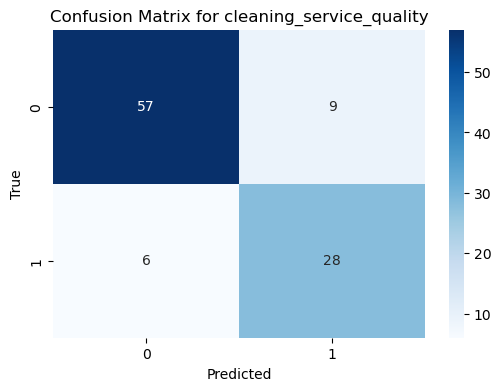

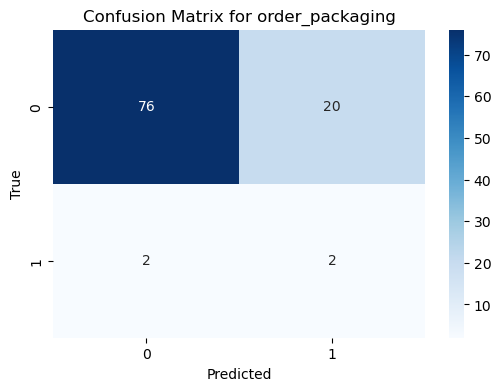

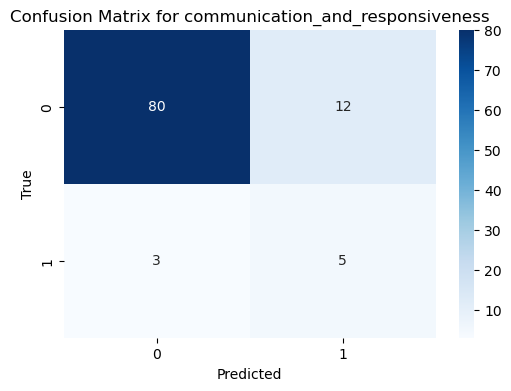

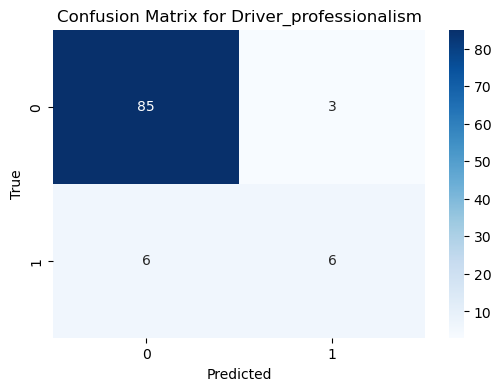

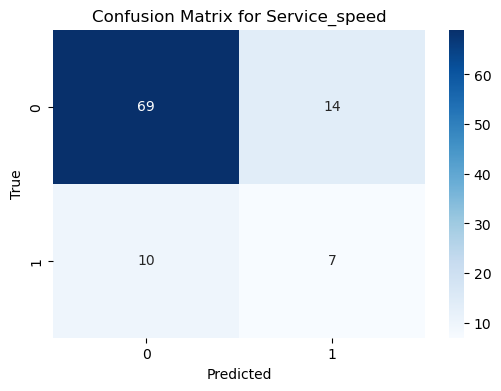

In [26]:
valid_df = pd.read_csv('data/labeled_presence/label_Study_1_reviews.csv')
valid_df = valid_df.iloc[:100,:] # Limit to first 100 (the labeled ones)

pred_df = df.iloc[:len(valid_df), :]


from sklearn.metrics import accuracy_score, recall_score
accuracy_scores = {}
recall_scores = {}
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy_scores[attr_name] = accuracy
    recall_scores[attr_name] = recall

print("Percentage reviews well classified for all attributes:")
well_classified = (pred_df[attribute_names].astype(int).values == valid_df[attribute_names].astype(int).values).all(axis=1).mean()
print(f" - Overall: {well_classified:.4f}\n")

print("Accuracy Scores per Attribute:")
for attr_name, score in accuracy_scores.items():
    print(f" - {attr_name}: {score:.4f}")

print("Recall Scores per Attribute:")
for attr_name, score in recall_scores.items():
    print(f" - {attr_name}: {score:.4f}")

# create a confusion matrix for each attribute
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'Confusion Matrix for {attr_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Percentage reviews well classified for all attributes:
 - Overall: 0.4200

Accuracy Scores per Attribute:
 - cleaning_service_quality: 0.9100
 - order_packaging: 0.8400
 - communication_and_responsiveness: 0.7100
 - Driver_professionalism: 0.8600
 - Service_speed: 0.6600
Recall Scores per Attribute:
 - cleaning_service_quality: 0.8929
 - order_packaging: 0.8750
 - communication_and_responsiveness: 0.2857
 - Driver_professionalism: 0.3636
 - Service_speed: 0.3226


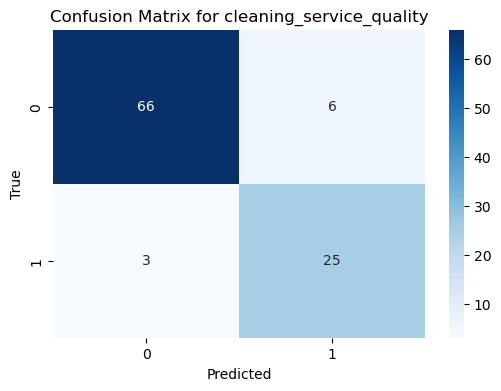

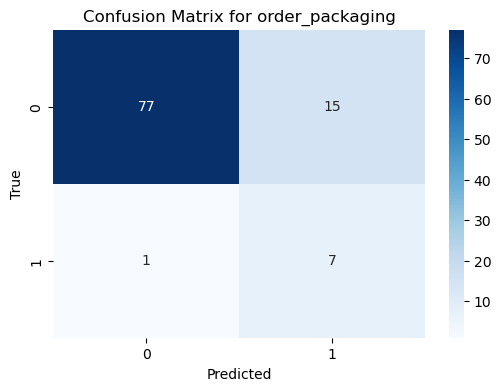

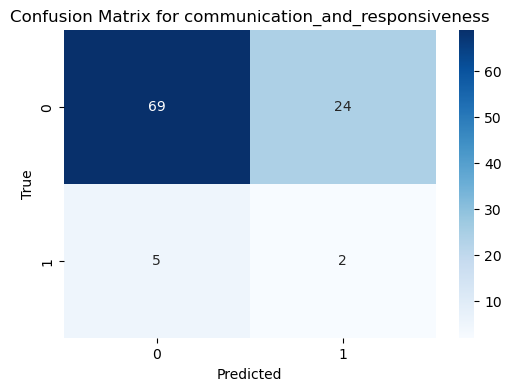

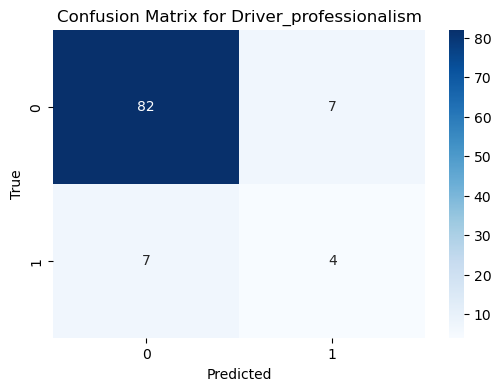

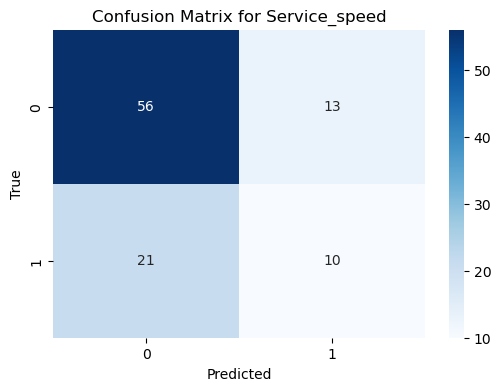

In [37]:
valid_df = pd.read_csv('data/labeled_presence/label_Study_1_reviews.csv')
valid_df = valid_df.iloc[2502:,:] 

pred_df_2 = df.iloc[2502:, :]

from sklearn.metrics import accuracy_score, recall_score
accuracy_scores = {}
recall_scores = {}
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy_scores[attr_name] = accuracy
    recall_scores[attr_name] = recall

print("Percentage reviews well classified for all attributes:")
well_classified = (pred_df[attribute_names].astype(int).values == valid_df[attribute_names].astype(int).values).all(axis=1).mean()
print(f" - Overall: {well_classified:.4f}\n")

print("Accuracy Scores per Attribute:")
for attr_name, score in accuracy_scores.items():
    print(f" - {attr_name}: {score:.4f}")

print("Recall Scores per Attribute:")
for attr_name, score in recall_scores.items():
    print(f" - {attr_name}: {score:.4f}")

# create a confusion matrix for each attribute
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[attr_name].astype(int).tolist()[:len(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'Confusion Matrix for {attr_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


In [ ]:
pred_df[attribute_names] = pred_df[attribute_names].astype(int)

pred_df.to_csv('data/predicted_attributes/predicted_Study_1_reviews.csv', index=False)

/tmp/ipykernel_2089917/1988264204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df[attribute_names] = pred_df[attribute_names].astype(int)
